Predictions: [0.75089315 0.74387077 0.86628815 0.74267579 0.97830557 0.93764502
 0.39967472 0.50159043 0.36607971 0.79396191 0.76826498 0.75729598]


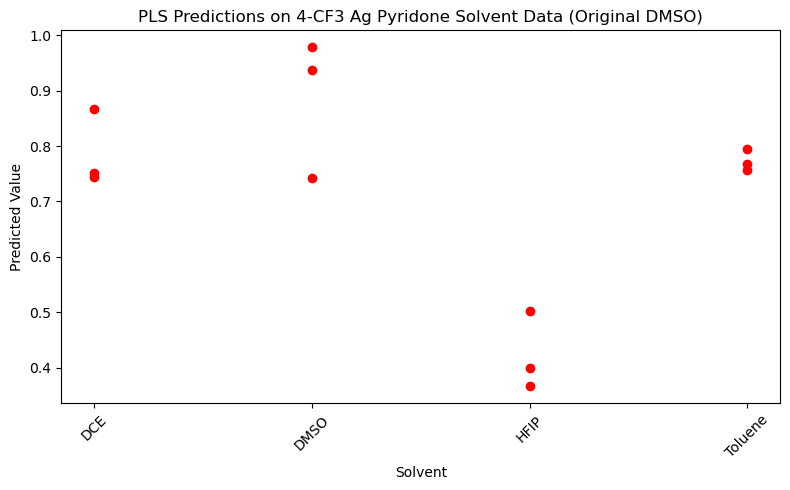

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression

root_directory = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_003/'

files = [f for f in os.listdir(root_directory) if f.lower().endswith('.csv')]
files.sort()
files = files[:33]

y_values = [
    0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9,
    0.8, 0.8, 0.8, 0.7, 0.7, 0.7, 0.6, 0.6, 0.6,
    0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 0.3, 0.3, 0.3,
    0.2, 0.2, 0.2
]
if len(files) != len(y_values):
    raise ValueError("Number of Y values does not match number of files!")

rows = []
for file, y_value in zip(files, y_values):
    file_path = os.path.join(root_directory, file)
    data = pd.read_csv(file_path, header=None, skiprows=1)
    x_column = data.iloc[:, 1].values
    row = np.insert(x_column, 0, y_value)
    rows.append(row)

min_len = min(len(r) for r in rows)
trimmed_rows = [r[:min_len] for r in rows]

columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
final_df = pd.DataFrame(trimmed_rows, columns=columns)

y = final_df.iloc[:, 0]
X = final_df.iloc[:, 1:]

n_components = 5
pls = PLSRegression(n_components=n_components)
pls.fit(X, y)

root_directory2 = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_002/'

files2 = [f for f in os.listdir(root_directory2) if f.lower().endswith('.csv')]
files2.sort()
files2 = files2[:12]

solvent_labels = (
    ['DCE'] * 3 +
    ['DMSO'] * 3 +
    ['HFIP'] * 3 +
    ['Toluene'] * 3
)
assert len(solvent_labels) == len(files2), "Solvent labels count mismatch with files!"

spectra = []
for file2 in files2:
    file_path2 = os.path.join(root_directory2, file2)
    data2 = pd.read_csv(file_path2, header=None, skiprows=1)
    x_column2 = data2.iloc[:, 1].values
    spectra.append(x_column2)

spectra_trimmed = [s[:min_len - 1] for s in spectra]

spectra_df = pd.DataFrame(spectra_trimmed,
                          columns=[f'x{i+1}' for i in range(min_len - 1)])

y_pred = pls.predict(spectra_df).ravel()
print("Predictions:", y_pred)

plt.figure(figsize=(8, 5))
plt.scatter(solvent_labels, y_pred, color='red')
plt.xlabel('Solvent')
plt.ylabel('Predicted Value')
plt.title('PLS Predictions on 4-CF3 Ag Pyridone Solvent Data (Original DMSO)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Predictions: [0.75089315 0.74387077 0.86628815 1.98961766 2.03750744 1.92522983
 0.39967472 0.50159043 0.36607971 0.79396191 0.76826498 0.75729598]


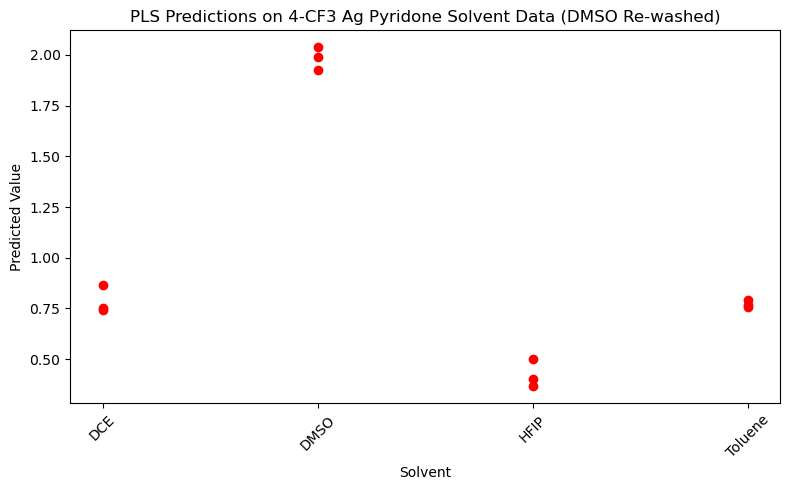

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression

root_directory = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_003/'

files = [f for f in os.listdir(root_directory) if f.lower().endswith('.csv')]
files.sort()
files = files[:33]

y_values = [
    0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9,
    0.8, 0.8, 0.8, 0.7, 0.7, 0.7, 0.6, 0.6, 0.6,
    0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 0.3, 0.3, 0.3,
    0.2, 0.2, 0.2
]
if len(files) != len(y_values):
    raise ValueError("Number of Y values does not match number of files!")

rows = []
for file, y_value in zip(files, y_values):
    file_path = os.path.join(root_directory, file)
    data = pd.read_csv(file_path, header=None, skiprows=1)
    x_column = data.iloc[:, 1].values
    row = np.insert(x_column, 0, y_value)
    rows.append(row)

min_len = min(len(r) for r in rows)
trimmed_rows = [r[:min_len] for r in rows]

columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
final_df = pd.DataFrame(trimmed_rows, columns=columns)

y = final_df.iloc[:, 0]
X = final_df.iloc[:, 1:]

n_components = 5
pls = PLSRegression(n_components=n_components)
pls.fit(X, y)

root_directory2 = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_002_DMSO Re-Wash/'

files2 = [f for f in os.listdir(root_directory2) if f.lower().endswith('.csv')]
files2.sort()
files2 = files2[:12]

solvent_labels = (
    ['DCE'] * 3 +
    ['DMSO'] * 3 +
    ['HFIP'] * 3 +
    ['Toluene'] * 3
)
assert len(solvent_labels) == len(files2), "Solvent labels count mismatch with files!"

spectra = []
for file2 in files2:
    file_path2 = os.path.join(root_directory2, file2)
    data2 = pd.read_csv(file_path2, header=None, skiprows=1)
    x_column2 = data2.iloc[:, 1].values
    spectra.append(x_column2)

spectra_trimmed = [s[:min_len - 1] for s in spectra]

spectra_df = pd.DataFrame(spectra_trimmed,
                          columns=[f'x{i+1}' for i in range(min_len - 1)])

y_pred = pls.predict(spectra_df).ravel()
print("Predictions:", y_pred)

plt.figure(figsize=(8, 5))
plt.scatter(solvent_labels, y_pred, color='red')
plt.xlabel('Solvent')
plt.ylabel('Predicted Value')
plt.title('PLS Predictions on 4-CF3 Ag Pyridone Solvent Data (DMSO Re-washed)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Spectra shape: (12, 7468)
Predictions: [0.75089315 0.74387077 0.86628815 0.74267579 0.97830557 0.93764502
 0.39967472 0.50159043 0.36607971 0.79396191 0.76826498 0.75729598]

Average Prediction per Solvent:
Solvent
DCE        0.787017
DMSO       0.886209
HFIP       0.422448
Toluene    0.773174
Name: Prediction, dtype: float64

Comparison to True Value (0.75):
         Avg Prediction  True Value     Error  Abs Error
Solvent                                                 
DCE            0.787017        0.75  0.037017   0.037017
DMSO           0.886209        0.75  0.136209   0.136209
HFIP           0.422448        0.75 -0.327552   0.327552
Toluene        0.773174        0.75  0.023174   0.023174

MAE vs true value: 0.13098803810748774


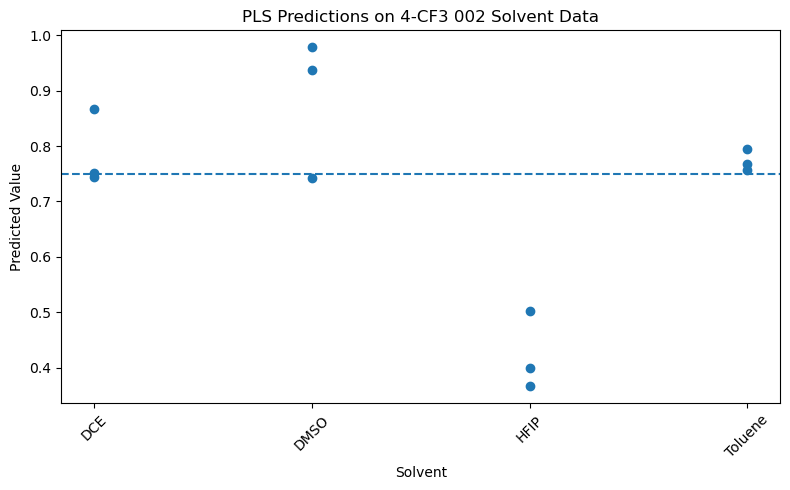

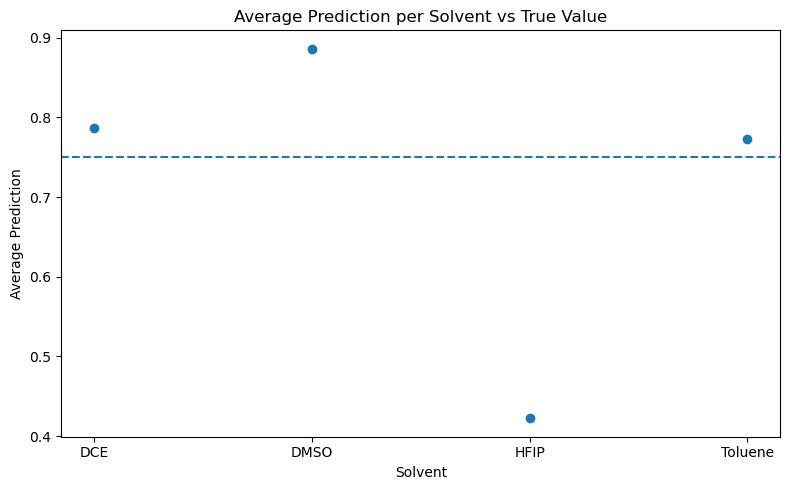

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression

root_directory = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_003/'

files = [file for file in os.listdir(root_directory) if file.lower().endswith('.csv')]
files.sort()

files = files[:33]

y_values = [0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9, 0.8, 0.8, 0.8,
           0.7, 0.7, 0.7, 0.6, 0.6, 0.6, 0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 
           0.3, 0.3, 0.3, 0.2, 0.2, 0.2]

if len(files) != len(y_values):
    raise ValueError("Number of Y values does not match number of files!")

rows = []

for file, y_value in zip(files, y_values):
    file_path = os.path.join(root_directory, file)
    data = pd.read_csv(file_path, header=None, skiprows=1)
    x_column = data.iloc[:, 1].values
    row = np.insert(x_column, 0, y_value)
    rows.append(row)
min_len = min(len(r) for r in rows)
trimmed_rows = [r[:min_len] for r in rows]

columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
final_df = pd.DataFrame(trimmed_rows, columns=columns)

y = final_df.iloc[:, 0]
X = final_df.iloc[:, 1:]

n_components = 5
pls = PLSRegression(n_components=n_components)
pls.fit(X, y)


# second dataset (predictions)
root_directory2 = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_002/'

files2 = [file2 for file2 in os.listdir(root_directory2) if file2.lower().endswith('.csv')]
files2.sort()
files2 = files2[:12]

solvent_labels = (
    ['DCE'] * 3 +
    ['DMSO'] * 3 +
    ['HFIP'] * 3 +
    ['Toluene'] * 3
)

assert len(solvent_labels) == len(files2), "Solvent labels count mismatch with files!"

spectra = []

for file2 in files2:
    file_path2 = os.path.join(root_directory2, file2)
    data2 = pd.read_csv(file_path2, header=None, skiprows=1)
    x_column2 = data2.iloc[:, 1].values
    spectra.append(x_column2)

spectra = np.array(spectra)
print(f"Spectra shape: {spectra.shape}")


spectra_trimmed = [s[:min_len - 1] for s in spectra]

spectra_df = pd.DataFrame(spectra_trimmed,
                          columns=[f'x{i+1}' for i in range(min_len - 1)])

y_pred = pls.predict(spectra_df).ravel()
print("Predictions:", y_pred)

# Averaging predictions

true_value = 0.75

results_df = pd.DataFrame({
    'Solvent': solvent_labels,
    'Prediction': y_pred
})

avg_predictions = results_df.groupby('Solvent')['Prediction'].mean()

print("\nAverage Prediction per Solvent:")
print(avg_predictions)

# MAE calculation

comparison = pd.DataFrame({
    'Avg Prediction': avg_predictions,
    'True Value': true_value,
    'Error': avg_predictions - true_value,
    'Abs Error': abs(avg_predictions - true_value)
})

print("\nComparison to True Value (0.75):")
print(comparison)

mae = np.mean(np.abs(avg_predictions - true_value))
print("\nMAE vs true value:", mae)

plt.figure(figsize=(8, 5))
plt.scatter(solvent_labels, y_pred)
plt.axhline(true_value, linestyle='--')
plt.xlabel('Solvent')
plt.ylabel('Predicted Value')
plt.title('PLS Predictions on 4-CF3 002 Solvent Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(avg_predictions.index, avg_predictions.values)
plt.axhline(true_value, linestyle='--')
plt.xlabel('Solvent')
plt.ylabel('Average Prediction')
plt.title('Average Prediction per Solvent vs True Value')
plt.tight_layout()
plt.show()

Prediction for YH_2025_009_DEE_A.CSV: y = 0.9258, MAE = 0.125782
Prediction for YH_2025_009_DEE_B.CSV: y = 1.0647, MAE = 0.264668
Prediction for YH_2025_009_DEE_C.CSV: y = 1.0425, MAE = 0.242479
Prediction for YH_2025_009_DMSO_A.CSV: y = 0.9668, MAE = 0.166809
Prediction for YH_2025_009_DMSO_B.CSV: y = 1.0724, MAE = 0.272376
Prediction for YH_2025_009_DMSO_C.CSV: y = 1.0454, MAE = 0.245431
Prediction for YH_2025_009_IPA_A.CSV: y = 0.9774, MAE = 0.177355
Prediction for YH_2025_009_IPA_B.CSV: y = 0.9885, MAE = 0.188515
Prediction for YH_2025_009_IPA_C.CSV: y = 1.0228, MAE = 0.222798
Prediction for YH_2025_009_Water_A.CSV: y = 0.7432, MAE = 0.056843
Prediction for YH_2025_009_Water_B.CSV: y = 0.7816, MAE = 0.018423
Prediction for YH_2025_009_Water_C.CSV: y = 0.7294, MAE = 0.070561

Average MAE across all test files: 0.1710

Full results saved to original_calibration_test_results.csv


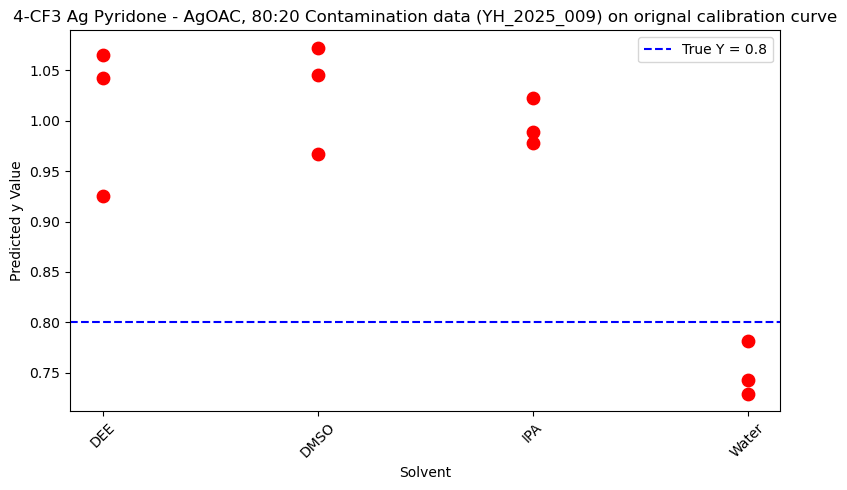

In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error

root_directory = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_003/'
test_directory = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

files = sorted([f for f in os.listdir(root_directory) if f.lower().endswith('.csv')])[:33]
y_values = [
    0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9,
    0.8, 0.8, 0.8, 0.7, 0.7, 0.7, 0.6, 0.6, 0.6,
    0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 0.3, 0.3, 0.3,
    0.2, 0.2, 0.2
]
if len(files) != len(y_values):
    raise ValueError("Number of Y values does not match number of files!")

rows = []
for file, y_val in zip(files, y_values):
    data = pd.read_csv(os.path.join(root_directory, file), header=None, skiprows=1)
    x_column = data.iloc[:, 1].values
    row = np.insert(x_column, 0, y_val)
    rows.append(row)

min_len = min(len(r) for r in rows)
rows = [r[:min_len] for r in rows]

columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
calib_df = pd.DataFrame(rows, columns=columns)

y_calib = calib_df['y'].values
X_calib = calib_df.drop('y', axis=1).values

n_components = 5
pls = PLSRegression(n_components=n_components)
pls.fit(X_calib, y_calib)

test_files = sorted([f for f in os.listdir(test_directory) if f.lower().endswith('.csv')])[:12]

spectra = []
for file2 in test_files:
    data2 = pd.read_csv(os.path.join(test_directory, file2), header=None, skiprows=1)
    x_column2 = data2.iloc[:, 1].values
    spectra.append(x_column2[:min_len-1])  # trim to match calibration

spectra_df = pd.DataFrame(spectra, columns=[f'x{i+1}' for i in range(min_len-1)])

y_pred = pls.predict(spectra_df.values).ravel()
true_y = 0.8  

mae_list = []
results = []

for file, pred in zip(test_files, y_pred):
    mae = mean_absolute_error([true_y], [pred])
    mae_list.append(mae)
    results.append({'test_file': file, 'y_pred': pred, 'true_y': true_y, 'mae': mae})
    print(f"Prediction for {file}: y = {pred:.4f}, MAE = {mae:.6f}")

average_mae = np.mean(mae_list)
print(f"\nAverage MAE across all test files: {average_mae:.4f}")

results_df = pd.DataFrame(results)
results_df.to_csv('original_calibration_test_results.csv', index=False)
print("\nFull results saved to original_calibration_test_results.csv")

solvent_labels = (
    ['DEE'] * 3 + ['DMSO'] * 3 + ['IPA'] * 3 + ['Water'] * 3
)
plt.figure(figsize=(8, 5))
plt.scatter(solvent_labels, y_pred, color='red', s=80)
plt.axhline(y=true_y, color='blue', linestyle='--', label=f'True Y = {true_y}')
plt.xticks(rotation=45)
plt.xlabel('Solvent')
plt.ylabel('Predicted y Value')
plt.title('4-CF3 Ag Pyridone - AgOAC, 80:20 Contamination data (YH_2025_009) on orignal calibration curve')
plt.legend()
plt.tight_layout()
plt.show()

Spectra shape: (12, 7468)
Predictions: [0.92578186 1.06466761 1.04247862 0.96680927 1.0723757  1.04543078
 0.97735487 0.9885149  1.02279788 0.74315748 0.78157716 0.72943856]

Average Prediction per Solvent:
Solvent
DEE      1.010976
DMSO     1.028205
IPA      0.996223
Water    0.751391
Name: Prediction, dtype: float64

Comparison to True Value (0.75):
         Avg Prediction  True Value     Error  Abs Error
Solvent                                                 
DEE            1.010976         0.8  0.210976   0.210976
DMSO           1.028205         0.8  0.228205   0.228205
IPA            0.996223         0.8  0.196223   0.196223
Water          0.751391         0.8 -0.048609   0.048609

MAE vs true value: 0.17100319226582844


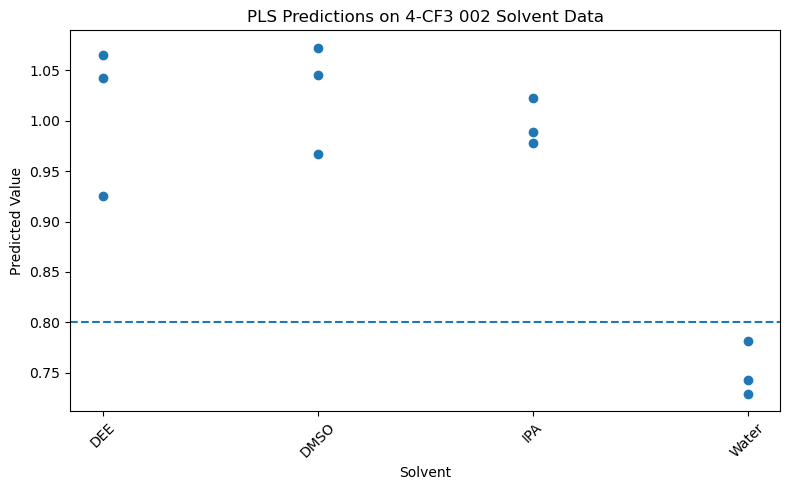

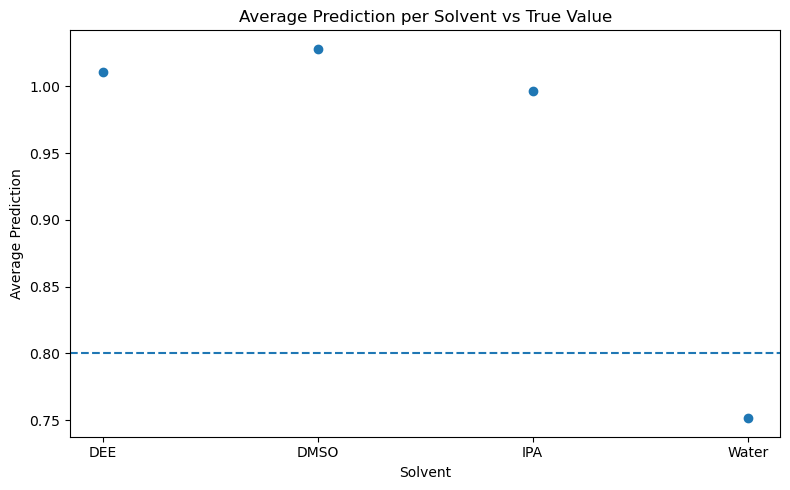

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression

root_directory = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_003/'

files = [file for file in os.listdir(root_directory) if file.lower().endswith('.csv')]
files.sort()

files = files[:33]

y_values = [0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9, 0.8, 0.8, 0.8,
           0.7, 0.7, 0.7, 0.6, 0.6, 0.6, 0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 
           0.3, 0.3, 0.3, 0.2, 0.2, 0.2]

if len(files) != len(y_values):
    raise ValueError("Number of Y values does not match number of files!")

rows = []

for file, y_value in zip(files, y_values):
    file_path = os.path.join(root_directory, file)
    data = pd.read_csv(file_path, header=None, skiprows=1)
    x_column = data.iloc[:, 1].values
    row = np.insert(x_column, 0, y_value)
    rows.append(row)
min_len = min(len(r) for r in rows)
trimmed_rows = [r[:min_len] for r in rows]

columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
final_df = pd.DataFrame(trimmed_rows, columns=columns)

y = final_df.iloc[:, 0]
X = final_df.iloc[:, 1:]

n_components = 5
pls = PLSRegression(n_components=n_components)
pls.fit(X, y)


# second dataset (predictions)
root_directory2 = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

files2 = [file2 for file2 in os.listdir(root_directory2) if file2.lower().endswith('.csv')]
files2.sort()
files2 = files2[:12]

solvent_labels = (
    ['DEE'] * 3 +
    ['DMSO'] * 3 +
    ['IPA'] * 3 +
    ['Water'] * 3
)

assert len(solvent_labels) == len(files2), "Solvent labels count mismatch with files!"

spectra = []

for file2 in files2:
    file_path2 = os.path.join(root_directory2, file2)
    data2 = pd.read_csv(file_path2, header=None, skiprows=1)
    x_column2 = data2.iloc[:, 1].values
    spectra.append(x_column2)

spectra = np.array(spectra)
print(f"Spectra shape: {spectra.shape}")


spectra_trimmed = [s[:min_len - 1] for s in spectra]

spectra_df = pd.DataFrame(spectra_trimmed,
                          columns=[f'x{i+1}' for i in range(min_len - 1)])

y_pred = pls.predict(spectra_df).ravel()
print("Predictions:", y_pred)

# Averaging predictions

true_value = 0.8

results_df = pd.DataFrame({
    'Solvent': solvent_labels,
    'Prediction': y_pred
})

avg_predictions = results_df.groupby('Solvent')['Prediction'].mean()

print("\nAverage Prediction per Solvent:")
print(avg_predictions)

# MAE calculation

comparison = pd.DataFrame({
    'Avg Prediction': avg_predictions,
    'True Value': true_value,
    'Error': avg_predictions - true_value,
    'Abs Error': abs(avg_predictions - true_value)
})

print("\nComparison to True Value (0.75):")
print(comparison)

mae = np.mean(np.abs(avg_predictions - true_value))
print("\nMAE vs true value:", mae)

plt.figure(figsize=(8, 5))
plt.scatter(solvent_labels, y_pred)
plt.axhline(true_value, linestyle='--')
plt.xlabel('Solvent')
plt.ylabel('Predicted Value')
plt.title('PLS Predictions on 4-CF3 002 Solvent Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(avg_predictions.index, avg_predictions.values)
plt.axhline(true_value, linestyle='--')
plt.xlabel('Solvent')
plt.ylabel('Average Prediction')
plt.title('Average Prediction per Solvent vs True Value')
plt.tight_layout()
plt.show()